In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
gr = pd.read_csv(r'C:\Users\santa\Desktop\ETL_cositas\workshop_02\data\raw\the_grammy_awards.csv')

In [3]:
gr.head()

,year,title,published_at,updated_at,category,nominee,artist,workers,img,winner
0,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Bad Guy,Billie Eilish,"Finneas O'Connell, producer; Rob Kinelski & Fi...",https://www.grammy.com/sites/com/files/styles/...,True
1,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,"Hey, Ma",Bon Iver,"BJ Burton, Brad Cook, Chris Messina & Justin V...",https://www.grammy.com/sites/com/files/styles/...,True
2,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,7 rings,Ariana Grande,"Charles Anderson, Tommy Brown, Michael Foster ...",https://www.grammy.com/sites/com/files/styles/...,True
3,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Hard Place,H.E.R.,"Rodney “Darkchild” Jerkins, producer; Joseph H...",https://www.grammy.com/sites/com/files/styles/...,True
4,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Talk,Khalid,"Disclosure & Denis Kosiak, producers; Ingmar C...",https://www.grammy.com/sites/com/files/styles/...,True


In [4]:
print("Shape or df dimensions:", gr.shape)
print("\nColumns:")
print(gr.columns.tolist())

Shape or df dimensions: (4810, 10)

Columns:
['year', 'title', 'published_at', 'updated_at', 'category', 'nominee', 'artist', 'workers', 'img', 'winner']


In [5]:
# Data types
print("Data types:", gr.dtypes)

Data types: year             int64
title           object
published_at    object
updated_at      object
category        object
nominee         object
artist          object
workers         object
img             object
winner            bool
dtype: object


In [8]:
# Missing values
print("Missing values:")
print(gr.isnull().sum())
print((gr.isnull().sum() / len(gr) * 100).round(2))

Missing values:
year               0
title              0
published_at       0
updated_at         0
category           0
nominee            6
artist          1840
workers         2190
img             1367
winner             0
dtype: int64
year             0.00
title            0.00
published_at     0.00
updated_at       0.00
category         0.00
nominee          0.12
artist          38.25
workers         45.53
img             28.42
winner           0.00
dtype: float64


In [7]:
# winner column
print("winner value counts:")
print(gr["winner"].value_counts())

winner value counts:
winner
True    4810
Name: count, dtype: int64


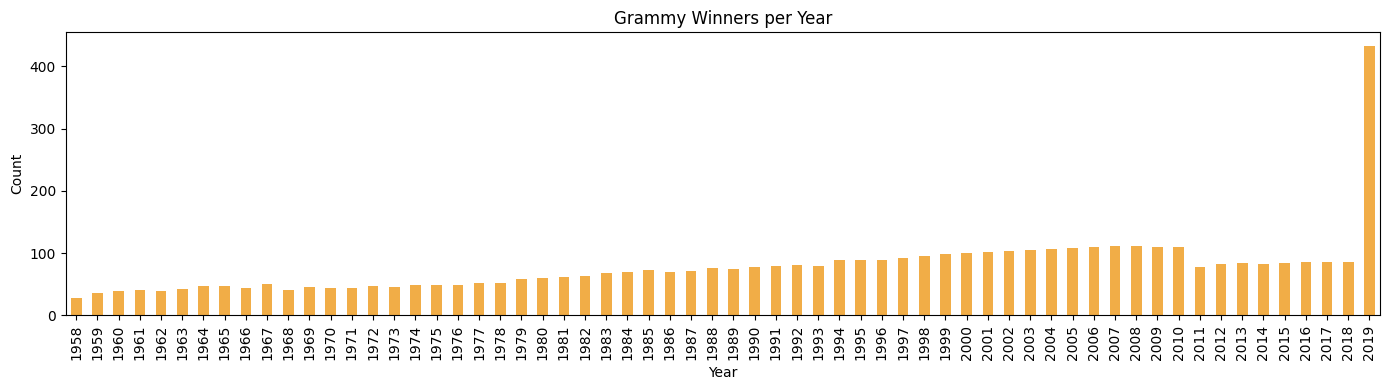

Year range: 1958 – 2019
Total unique years: 62


In [12]:
#year distribution
plt.figure(figsize=(14, 4))
gr["year"].value_counts().sort_index().plot(kind="bar", color="#EF9F27", alpha=0.85)
plt.title("Grammy Winners per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(f"Year range: {gr['year'].min()} – {gr['year'].max()}")
print(f"Total unique years: {gr['year'].nunique()}")

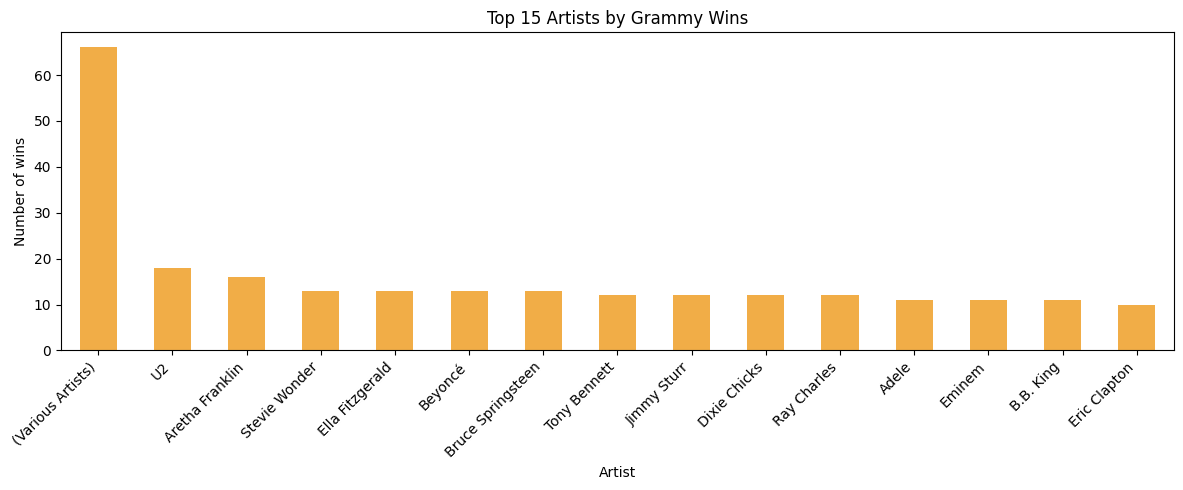

In [23]:
#top winning artists
top_winners = (
    gr[gr["artist"].notna() & (gr["artist"] != "N/A")]
    ["artist"]
    .value_counts()
    .head(15)
)
 
plt.figure(figsize=(12, 5))
top_winners.plot(kind="bar", color="#EF9F27", alpha=0.85)
plt.title("Top 15 Artists by Grammy Wins")
plt.xlabel("Artist")
plt.ylabel("Number of wins")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [13]:
#Category analysis
print(f"Total unique categories: {gr['category'].nunique()}")
print("\nTop 15 categories by number of winners:")
print(gr["category"].value_counts().head(15).to_string())

Total unique categories: 638

Top 15 categories by number of winners:
category
Song Of The Year                         70
Record Of The Year                       69
Album Of The Year                        66
Best Opera Recording                     64
Best Album Notes                         63
Best Instrumental Composition            55
Best Country Song                        55
Best New Artist                          51
Best Historical Album                    44
Best Chamber Music Performance           43
Best Instrumental Arrangement            39
Best Country Instrumental Performance    38
Best Orchestral Performance              36
Best Classical Album                     35
Best Bluegrass Album                     34


In [14]:
#artist nulls
print("Rows where artist is null:", gr["artist"].isnull().sum())
print("\nExample — categories with null artist (songwriter/producer awards):")
print(gr[gr["artist"].isnull()][["category", "nominee", "artist"]].head(8).to_string())

Rows where artist is null: 1840

Example — categories with null artist (songwriter/producer awards):
            category                      nominee artist
16  Song Of The Year                      Bad Guy    NaN
17  Song Of The Year  Always Remember Us This Way    NaN
18  Song Of The Year         Bring My Flowers Now    NaN
19  Song Of The Year                   Hard Place    NaN
20  Song Of The Year                        Lover    NaN
21  Song Of The Year      Norman F***ing Rockwell    NaN
22  Song Of The Year            Someone You Loved    NaN
23  Song Of The Year                  Truth Hurts    NaN


In [15]:
# nominee nulls
print("\nRows where nominee is null:", gr["nominee"].isnull().sum())
print(gr[gr["nominee"].isnull()][["year", "category", "nominee"]].to_string())


Rows where nominee is null: 6
      year                                   category nominee
2261  2000         Remixer of the Year, Non-Classical     NaN
2359  1999         Remixer Of The Year, Non-Classical     NaN
2454  1998         Remixer Of The Year, Non-classical     NaN
2547  1997         Remixer Of The Year, Non-Classical     NaN
4525  1965          Best New Country & Western Artist     NaN
4573  1964  Best New Country & Western Artist Of 1964     NaN


In [17]:
# workers nulls
print("\nRows where workers is null:", gr["workers"].isnull().sum())
print("Expected: artist-specific awards don't list behind-the-scenes workers")


Rows where workers is null: 2190
Expected: artist-specific awards don't list behind-the-scenes workers


In [18]:
# Probable columns to drop
print("Columns to drop in cleaning phase:")
print("  - 'img'         : image URL, not useful for analysis")
print("  - 'title'       : ceremony name, derivable from 'year'")
print("  - 'published_at': record metadata, not needed")
print("  - 'updated_at'  : record metadata, not needed")

Columns to drop in cleaning phase:
  - 'img'         : image URL, not useful for analysis
  - 'title'       : ceremony name, derivable from 'year'
  - 'published_at': record metadata, not needed
  - 'updated_at'  : record metadata, not needed
